In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import classification_report, roc_curve, auc, ConfusionMatrixDisplay, roc_auc_score

In [2]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('onlinefraud_cleaned.csv')
df.head(10)

,hour_of_day,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,nameOrig,nameDest,is_Merchant_Dest,errorBalanceOrig,errorBalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.0,0.00,C1231006815,M1979787155,1,0.00,0.00,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.0,0.00,C1666544295,M2044282225,1,0.00,0.00,0
2,1,TRANSFER,181.00,181.00,0.00,0.0,0.00,C1305486145,C553264065,0,0.00,181.00,1
3,1,CASH_OUT,181.00,181.00,0.00,21182.0,0.00,C840083671,C38997010,0,0.00,21363.00,1
4,1,PAYMENT,11668.14,41554.00,29885.86,0.0,0.00,C2048537720,M1230701703,1,0.00,0.00,0
5,1,PAYMENT,7817.71,53860.00,46042.29,0.0,0.00,C90045638,M573487274,1,0.00,0.00,0
6,1,PAYMENT,7107.77,183195.00,176087.23,0.0,0.00,C154988899,M408069119,1,0.00,0.00,0
7,1,PAYMENT,7861.64,176087.23,168225.59,0.0,0.00,C1912850431,M633326333,1,0.00,0.00,0
8,1,PAYMENT,4024.36,2671.00,0.00,0.0,0.00,C1265012928,M1176932104,1,1353.36,0.00,0
9,1,DEBIT,5337.77,41720.00,36382.23,41898.0,40348.79,C712410124,C195600860,0,0.00,6886.98,0


In [4]:
df = pd.get_dummies(df, columns= ['type'], drop_first= True, dtype= int)

In [5]:
df

,hour_of_day,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,nameOrig,nameDest,is_Merchant_Dest,errorBalanceOrig,errorBalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.00,160296.36,0.00,0.00,C1231006815,M1979787155,1,0.0,0.000000e+00,0,0,0,1,0
1,1,1864.28,21249.00,19384.72,0.00,0.00,C1666544295,M2044282225,1,0.0,0.000000e+00,0,0,0,1,0
2,1,181.00,181.00,0.00,0.00,0.00,C1305486145,C553264065,0,0.0,1.810000e+02,1,0,0,0,1
3,1,181.00,181.00,0.00,21182.00,0.00,C840083671,C38997010,0,0.0,2.136300e+04,1,1,0,0,0
4,1,11668.14,41554.00,29885.86,0.00,0.00,C2048537720,M1230701703,1,0.0,0.000000e+00,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,23,339682.13,339682.13,0.00,0.00,339682.13,C786484425,C776919290,0,0.0,0.000000e+00,1,1,0,0,0
6362616,23,6311409.28,6311409.28,0.00,0.00,0.00,C1529008245,C1881841831,0,0.0,6.311409e+06,1,0,0,0,1
6362617,23,6311409.28,6311409.28,0.00,68488.84,6379898.11,C1162922333,C1365125890,0,0.0,1.000000e-02,1,1,0,0,0
6362618,23,850002.52,850002.52,0.00,0.00,0.00,C1685995037,C2080388513,0,0.0,8.500025e+05,1,0,0,0,1


In [6]:
df.columns

Index(['hour_of_day', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'nameOrig', 'nameDest',
       'is_Merchant_Dest', 'errorBalanceOrig', 'errorBalanceDest', 'isFraud',
       'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER'],
      dtype='str')

In [7]:
X = df.drop(['nameOrig', 'nameDest','is_Merchant_Dest', 'errorBalanceOrig', 'errorBalanceDest'], axis= 1)
y = X.pop('isFraud')

# train+val and test
x_temp, x_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# train and validation
x_train, x_val, y_train, y_val = train_test_split(
    x_temp,
    y_temp,
    test_size=0.1765,  # ~15% total
    stratify=y_temp,
    random_state=42
)

scaler = StandardScaler()

# Fit only on training data
x_train_scaled = scaler.fit_transform(x_train)

# Use the same scaler for val and test
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

In [8]:
# Keep only 1 million rows
# Sample for model comparison
X_sample, _, y_sample, _ = train_test_split(
    x_train_scaled,
    y_train,
    train_size=1_000_000,
    stratify=y_train,
    random_state=42
)

X_sample.shape, y_sample.shape

((1000000, 10), (1000000,))

In [9]:
x_train_scaled.shape, x_val_scaled.shape, x_test_scaled.shape

((4453674, 10), (954553, 10), (954393, 10))

In [10]:
def model_comparison_evaluate(classifiers, X, y, n_splits=5):
    """
    Compare multiple classification models using Stratified K-Fold Cross Validation.

    Parameters
    ----------
    classifiers : dict
        Dictionary containing model names and model objects.

        Example:
        {
            'Logistic Regression': LogisticRegression(),
            'Random Forest': RandomForestClassifier()
        }

    X : pandas.DataFrame, pandas.Series, numpy.ndarray
        Feature matrix (input variables).

        Accepted formats:
        - pandas DataFrame
        - pandas Series
        - NumPy array

        Shape:
        (n_samples, n_features)

    y : pandas.Series, numpy.ndarray, list
        Target labels.

        Accepted formats:
        - pandas Series
        - NumPy array
        - Python list

        Shape:
        (n_samples,)

    n_splits : int, default=5
        Number of folds for cross-validation.

    Returns
    -------
    None
        Prints evaluation results for each model.
    """

    # Stratified K-Fold keeps class distribution balanced
    skfold = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    # PR-AUC scorer
    pr_auc_scorer = make_scorer(
        average_precision_score,
        response_method='predict_proba'
    )

    scoring_metrics = {
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc',
        'pr_auc': pr_auc_scorer
    }

    print('K-Fold Cross-Validation Evaluation\n')

    for name, model in classifiers.items():

        print('=' * 50)
        print(f'Model: {name}')
        print('=' * 50)

        for metric_name, scoring_method in scoring_metrics.items():

            scores = cross_val_score(
                estimator=model,
                X=X,
                y=y,
                scoring=scoring_method,
                cv=skfold,
                n_jobs= -1
            )

            print(
                f'{metric_name:<10}: '
                f'Mean = {scores.mean():.4f} | '
                f'Std = {scores.std():.4f}'
            )

        print('\n')

In [11]:
classifiers = {

    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        learning_rate=0.1,
        max_iter=200,
        max_depth=10,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=10,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=10,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        objective='binary',
        random_state=42,
    ),

    'CatBoost': CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=10,
        loss_function='Logloss',
        eval_metric='AUC',
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0,
    )
}

In [ ]:
model_comparison_evaluate(classifiers, X_sample, y_sample)

In [13]:
lr_model = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )

rf_model = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

lgbm_model = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=10,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        objective='binary',
        random_state=42,
    )

# XGBoost
xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=10,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
    )

# Logistic Regression
lr_model.fit(x_train_scaled, y_train)

# Random Forest
rf_model.fit(x_train_scaled, y_train)

# Light GBM
lgbm_model.fit(
    x_train_scaled,
    y_train,
    eval_set=[(x_val_scaled, y_val)],
    eval_metric='auc'
)


xgb_model.fit(
    x_train_scaled,
    y_train,
    eval_set=[(x_val_scaled, y_val)],
    verbose= False
)

[LightGBM] [Info] Number of positive: 5749, number of negative: 4447925
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.082627 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1312
[LightGBM] [Info] Number of data points in the train set: 4453674, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [63]:
# XGBoost
xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=10,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
    )

xgb_model.fit(
    x_train_scaled,
    y_train,
    eval_set=[(x_val_scaled, y_val)],
    verbose= False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [14]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost" : xgb_model,
    "LightGBM": lgbm_model
}

for name, model in models.items():
    pred_proba = model.predict_proba(x_val_scaled)[:, 1]
    auc_score = roc_auc_score(y_val, pred_proba)
    print(f"{name}: {auc_score:.4f}")

Logistic Regression: 0.9909
Random Forest: 0.9990
XGBoost: 0.9999
LightGBM: 0.9999


In [15]:
# Logistic Regression
lr_y_pred = lr_model.predict(x_test_scaled)
lr_y_pred_score = lr_model.predict_proba(x_test_scaled)[:, 1]

print("===========================================================")
print("Logistic Regression:")
print(
    classification_report(
        y_test,
        lr_y_pred,
        digits= 4,
        labels=[0, 1],
        target_names=['Non-Fraud', 'Fraud']
    )
)
print("===========================================================")


# Random Forest
rf_y_pred = rf_model.predict(x_test_scaled)
rf_y_pred_score = rf_model.predict_proba(x_test_scaled)[:, 1]

print("Random Forest:")
print(
    classification_report(
        y_test,
        rf_y_pred,
        digits= 4,
        labels=[0, 1],
        target_names=['Non-Fraud', 'Fraud']
    )
)

print("===========================================================")

# XGBoost
xgb_y_pred = xgb_model.predict(x_test_scaled)
xgb_y_pred_score = xgb_model.predict_proba(x_test_scaled)[:,1]

print("XGBoost:")
print(
    classification_report(
        y_test,
        xgb_y_pred,
        digits=4,
        labels= [0, 1],
        target_names= ['Non-Fraud', 'Fraud']
    )
)

print("===========================================================")

# Light GBM
lgbm_y_pred = lgbm_model.predict(x_test_scaled)
lgbm_y_pred_score = lgbm_model.predict_proba(x_test_scaled)[:,1]

print("LightGBM:")
print(
    classification_report(
        y_test,
        lgbm_y_pred,
        digits=4,
        labels= [0, 1],
        target_names= ['Non-Fraud', 'Fraud']
    )
)

print("===========================================================")

Logistic Regression:
              precision    recall  f1-score   support

   Non-Fraud     0.9999    0.9516    0.9752    953161
       Fraud     0.0245    0.9407    0.0478      1232

    accuracy                         0.9516    954393
   macro avg     0.5122    0.9462    0.5115    954393
weighted avg     0.9987    0.9516    0.9740    954393

Random Forest:
              precision    recall  f1-score   support

   Non-Fraud     0.9997    1.0000    0.9999    953161
       Fraud     0.9752    0.7971    0.8772      1232

    accuracy                         0.9997    954393
   macro avg     0.9875    0.8985    0.9385    954393
weighted avg     0.9997    0.9997    0.9997    954393

XGBoost:
              precision    recall  f1-score   support

   Non-Fraud     0.9998    0.9998    0.9998    953161
       Fraud     0.8519    0.8823    0.8668      1232

    accuracy                         0.9997    954393
   macro avg     0.9259    0.9411    0.9333    954393
weighted avg     0.9997    0.

#### Logistic Regression

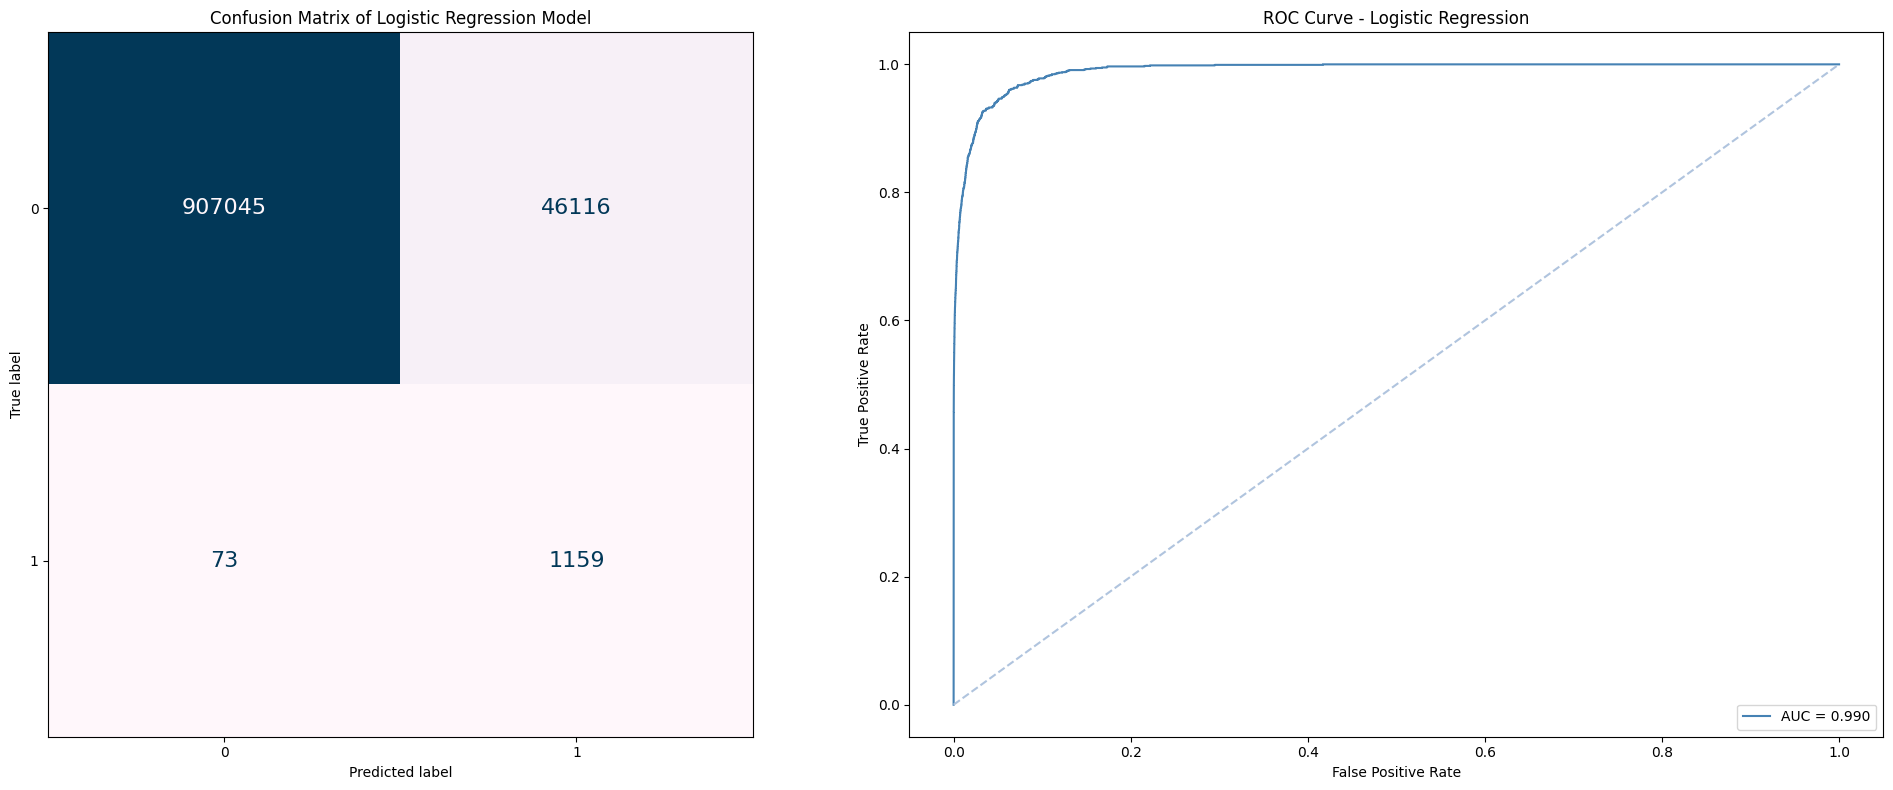

In [16]:
from sklearn.metrics import auc
fig, ax = plt.subplots(1, 2, figsize=(20,8))

# Confusion Matrix
ax[0].set_title('Confusion Matrix of Logistic Regression Model')
ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_y_pred,
    colorbar=False,
    values_format='',
    cmap='PuBu',
    ax=ax[0],
    text_kw={'fontsize': 16}
)
ax[0].grid(False)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, lr_y_pred_score)
roc_auc = auc(fpr, tpr)

ax[1].set_title('ROC Curve - Logistic Regression')
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', c='steelblue')
ax[1].plot([0,1], [0,1], '--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

plt.tight_layout()
plt.show()

#### Random Forest

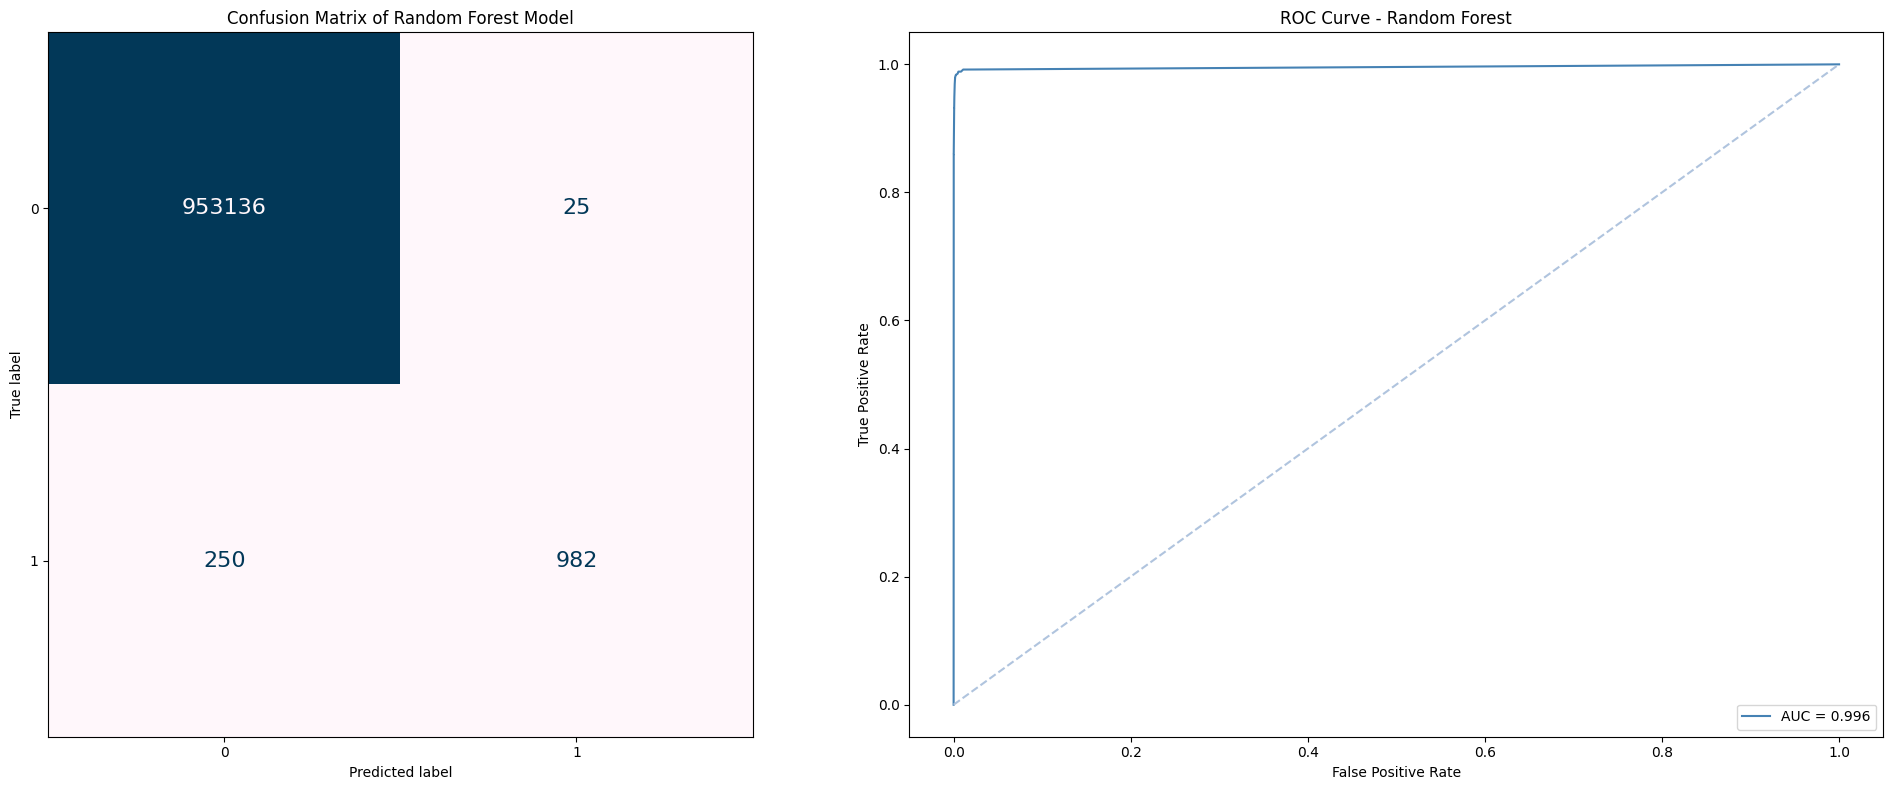

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(20,8))

# Confusion Matrix
ax[0].set_title('Confusion Matrix of Random Forest Model')
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_y_pred,
    colorbar=False,
    values_format='',
    cmap='PuBu',
    ax=ax[0],
    text_kw={'fontsize': 16}
)
ax[0].grid(False)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, rf_y_pred_score)
roc_auc = auc(fpr, tpr)

ax[1].set_title('ROC Curve - Random Forest')
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', c='steelblue')
ax[1].plot([0,1], [0,1], '--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

plt.tight_layout()
plt.show()

#### XGBoost

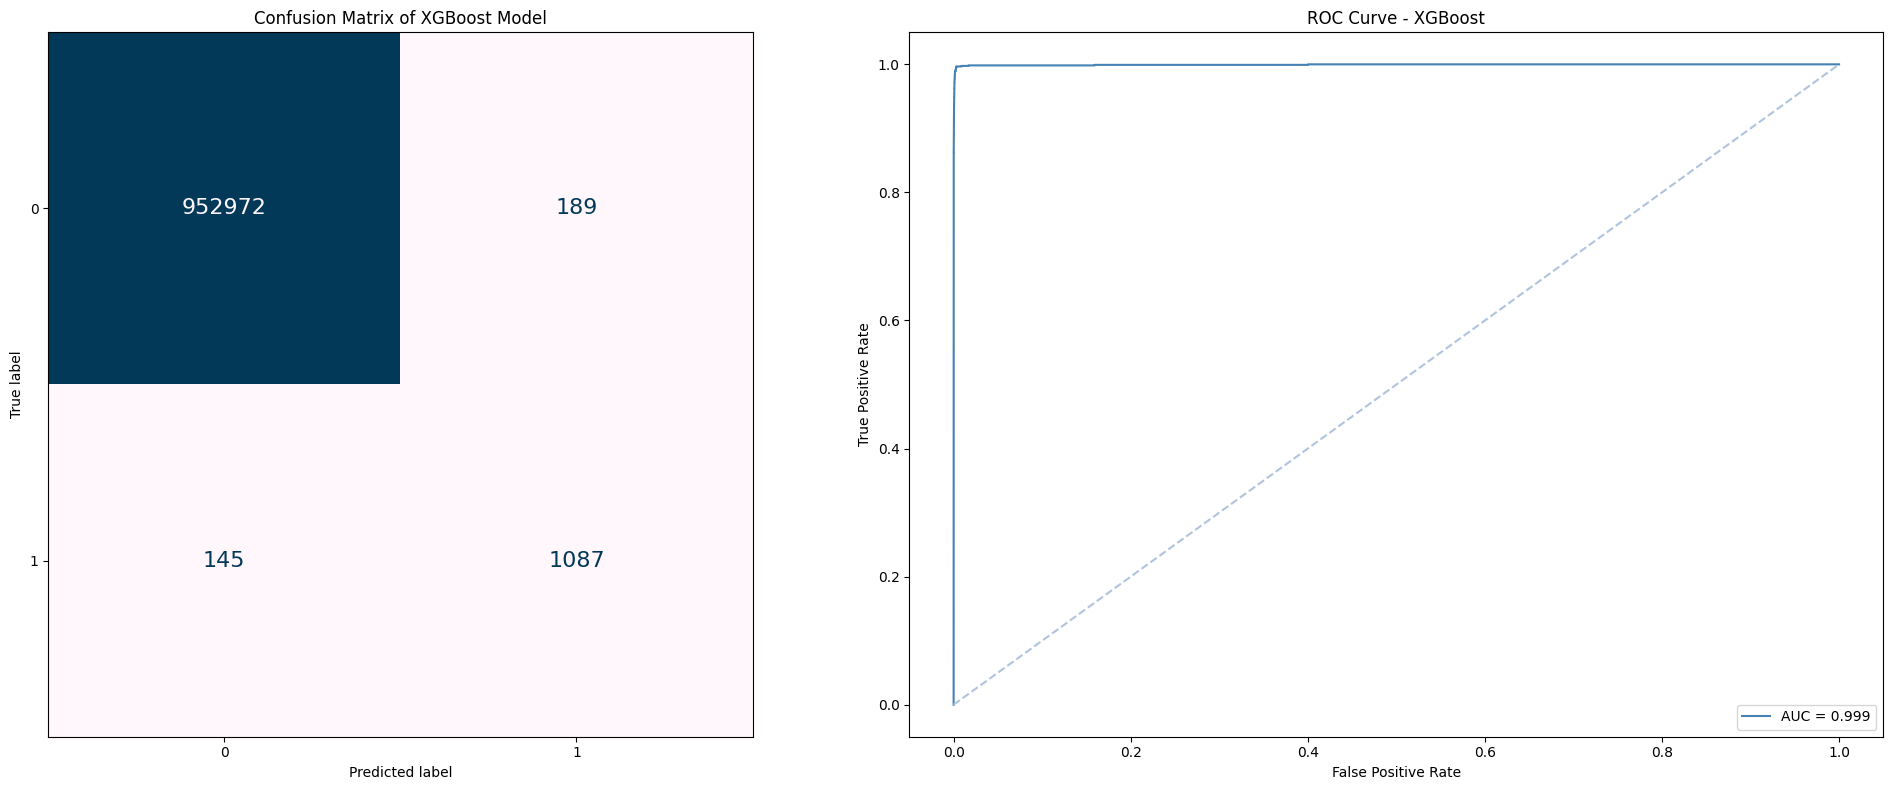

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(20,8))

# Confusion Matrix
ax[0].set_title('Confusion Matrix of XGBoost Model')
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_y_pred,
    colorbar=False,
    values_format='',
    cmap='PuBu',
    ax=ax[0],
    text_kw={'fontsize': 16}
)
ax[0].grid(False)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, xgb_y_pred_score)
roc_auc = auc(fpr, tpr)

ax[1].set_title('ROC Curve - XGBoost')
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', c='steelblue')
ax[1].plot([0,1], [0,1], '--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

plt.tight_layout()
plt.show()

#### Light GBM

Text(0.5, 0, 'False Positive Rate')

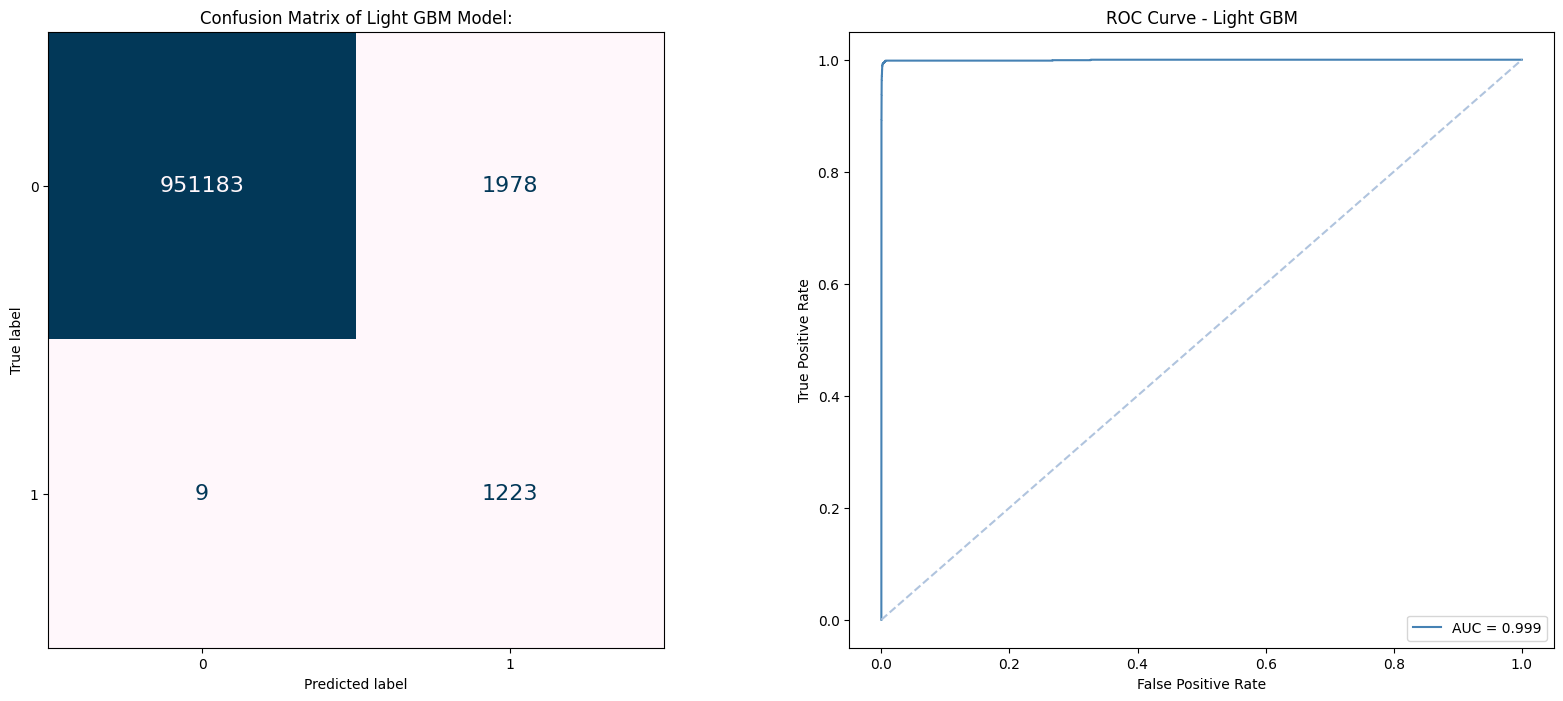

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(20,8))
ax[0].set_title('Confusion Matrix of Light GBM Model:')
ConfusionMatrixDisplay.from_predictions(y_test, lgbm_y_pred, colorbar=False, values_format='', cmap='PuBu', ax=ax[0],text_kw={'fontsize': 16})
ax[0].grid(False)


fpr, tpr, thresholds = roc_curve(y_test, lgbm_y_pred_score)
roc_auc = auc(fpr, tpr)                       
ax[1].set_title('ROC Curve - Light GBM')
ax[1].plot(fpr, tpr, label = 'AUC = %0.3f' % roc_auc, c='steelblue')
ax[1].plot([0,1],[0,1],'--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')

- Note: Logistic Regression doesn't have feature importance

In [20]:
# Random Forest
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

          feature  importance
2   oldbalanceOrg    0.295895
3  newbalanceOrig    0.169624
1          amount    0.162902
9   type_TRANSFER    0.087370
8    type_PAYMENT    0.062881
0     hour_of_day    0.062605
5  newbalanceDest    0.056450
6   type_CASH_OUT    0.052559
4  oldbalanceDest    0.049382
7      type_DEBIT    0.000333


In [21]:
# XGBoost
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

          feature  importance
3  newbalanceOrig    0.379521
8    type_PAYMENT    0.292879
9   type_TRANSFER    0.083865
6   type_CASH_OUT    0.074142
2   oldbalanceOrg    0.051130
5  newbalanceDest    0.042714
1          amount    0.027017
0     hour_of_day    0.020338
7      type_DEBIT    0.020253
4  oldbalanceDest    0.008141


In [22]:
# Light GBM
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': lgbm_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

          feature  importance
2   oldbalanceOrg        1638
1          amount        1612
5  newbalanceDest         827
4  oldbalanceDest         656
0     hour_of_day         630
3  newbalanceOrig         211
6   type_CASH_OUT         157
9   type_TRANSFER         138
8    type_PAYMENT         107
7      type_DEBIT          24
